<a href="https://colab.research.google.com/github/thaynagoncalves/projeto-final-IA/blob/main/ProjetoFInal_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predição da retenção de habilidades de estudantes com Aprendizado de Máquina

## Projeto Final — Aprendizado de Máquina

**Integrantes:**  
- Luan Dantas Melo  
- Lucas Lima Celino
- Thayná Luzia Gonçalves Lima  

**Fonte dos dados:** [AI Impact on Students — Kaggle](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students)

**Objetivo:** desenvolver e comparar modelos de regressão capazes de estimar a pontuação de retenção de habilidades de estudantes a partir de características acadêmicas, hábitos de estudo e uso de IA generativa.

**Atributo-alvo:** `Skill_Retention_Score`.

**Tipo da tarefa:** regressão, pois o atributo-alvo é um valor numérico contínuo.

### Atributos preditivos

Serão inicialmente consideradas as variáveis acadêmicas, comportamentais e relacionadas ao uso de IA. As colunas `Student_ID`, `Post_Semester_GPA` e `Burnout_Risk_Level` serão removidas:

- `Student_ID` é apenas um identificador;
- `Post_Semester_GPA` é uma informação obtida após o semestre e pode provocar vazamento temporal caso o objetivo seja prever a retenção antes do resultado final;
- `Burnout_Risk_Level` também representa uma avaliação final relacionada ao estudante e pode tornar a previsão artificialmente otimista.

Essa escolha torna o problema mais realista: prever a retenção com informações disponíveis antes ou durante o semestre.

## 1. Preparação do ambiente

Esta seção importa as bibliotecas necessárias e configura a reprodução dos resultados.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

print("Python:", sys.version.split()[0])

Python: 3.12.13


## 2. Carregamento dos dados

O código abaixo tenta carregar o arquivo por uma URL `raw` do GitHub.

In [2]:
# Depois de enviar o CSV ao GitHub, substitua pela URL RAW do arquivo.
GITHUB_RAW_URL = "https://raw.githubusercontent.com/thaynagoncalves/projeto-final-IA/refs/heads/main/ai_student_impact_dataset.csv"

def carregar_dados():
    if GITHUB_RAW_URL.strip():
        print("Carregando dados do GitHub...")
        return pd.read_csv(GITHUB_RAW_URL)

    print("URL do GitHub ainda não configurada. Carregando do Kaggle...")
    try:
        import kagglehub
    except ImportError:
        !pip -q install kagglehub
        import kagglehub

    pasta = Path(kagglehub.dataset_download("laveshjadon/ai-impact-on-students"))
    arquivos_csv = list(pasta.rglob("*.csv"))

    if not arquivos_csv:
        raise FileNotFoundError("Nenhum arquivo CSV foi encontrado no conjunto de dados.")

    print("Arquivo encontrado:", arquivos_csv[0].name)
    return pd.read_csv(arquivos_csv[0])

df = carregar_dados()
df.head()

Carregando dados do GitHub...


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


# 3. Descrição do problema

O conjunto de dados contém informações sobre estudantes, desempenho acadêmico, horas de estudo tradicional, uso de ferramentas de IA, dependência percebida de IA, ansiedade em provas e retenção de habilidades.

O objetivo da aplicação é estimar `Skill_Retention_Score`. Como essa variável assume valores numéricos em uma escala contínua, o problema é de **regressão**.

A aplicação pode ajudar a investigar quais características estão mais associadas à retenção de habilidades. Entretanto, os resultados não devem ser interpretados como relações de causa e efeito.

# 4. Compreensão dos dados

Nesta seção serão analisados:

- quantidade de registros e atributos;
- tipos das variáveis;
- valores ausentes;
- duplicações;
- possíveis inconsistências;
- distribuição do atributo-alvo.


In [3]:
print(f"O conjunto possui {df.shape[0]:,} registros e {df.shape[1]} atributos.")
print("\nTipos das variáveis:")
display(df.dtypes.to_frame("tipo"))

O conjunto possui 50,000 registros e 16 atributos.

Tipos das variáveis:


,tipo
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


In [4]:
# Resumo estrutural
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

**Interpretação:** as variáveis numéricas representam notas, horas de estudo, níveis e pontuações. As variáveis do tipo `object` representam categorias, como área de estudo, ano acadêmico, principal uso da IA e política institucional. A coluna booleana indica se o estudante possui assinatura paga.

In [5]:
# Estatísticas das variáveis numéricas
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,125000.500000,14433.901067,100001.000,112500.75000,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


**Interpretação:** a tabela permite verificar média, dispersão, valores mínimos, máximos e quartis. Valores mínimos e máximos devem ser comparados com o significado de cada variável para identificar números impossíveis ou suspeitos.

In [6]:
# Valores ausentes
ausentes = pd.DataFrame({
    "quantidade": df.isna().sum(),
    "percentual": (df.isna().mean() * 100).round(2)
}).sort_values("quantidade", ascending=False)

display(ausentes)
print("Total de valores ausentes:", int(df.isna().sum().sum()))

,quantidade,percentual
Student_ID,0,0.0
Major_Category,0,0.0
Year_of_Study,0,0.0
Pre_Semester_GPA,0,0.0
Weekly_GenAI_Hours,0,0.0
Primary_Use_Case,0,0.0
Prompt_Engineering_Skill,0,0.0
Tool_Diversity,0,0.0
Paid_Subscription,0,0.0
Traditional_Study_Hours,0,0.0


Total de valores ausentes: 0


**Interpretação:** caso existam valores ausentes, eles serão tratados dentro do `Pipeline`, usando mediana para variáveis numéricas e moda para variáveis categóricas. Isso evita calcular estatísticas do conjunto de teste durante o treinamento.

In [7]:
# Duplicações
duplicados = int(df.duplicated().sum())
print("Linhas totalmente duplicadas:", duplicados)

Linhas totalmente duplicadas: 0


**Interpretação:** linhas totalmente duplicadas podem dar peso excessivo a determinados exemplos. Se forem encontradas, serão removidas antes da separação entre treino e teste.

In [8]:
# Remoção de duplicações, se existirem
df = df.drop_duplicates().reset_index(drop=True)
print("Dimensão após remoção de duplicações:", df.shape)

Dimensão após remoção de duplicações: (50000, 16)


In [9]:
# Categorias e frequências
colunas_categoricas = df.select_dtypes(include=["object", "bool"]).columns

for coluna in colunas_categoricas:
    print(f"\n--- {coluna} ---")
    display(df[coluna].value_counts(dropna=False).to_frame("frequência"))


--- Major_Category ---


,frequência
Major_Category,
STEM,15059
Business,12538
Humanities,9994
Medical,6476
Arts,5933



--- Year_of_Study ---


,frequência
Year_of_Study,
Junior,11045
Freshman,11031
Senior,10634
Sophomore,9860
Graduate,7430



--- Primary_Use_Case ---


...

,frequência
Paid_Subscription,
False,28846
True,21154



--- Institutional_Policy ---


,frequência
Institutional_Policy,
Allowed_With_Citation,25224
Actively_Encouraged,14988
Strict_Ban,9788



--- Burnout_Risk_Level ---


,frequência
Burnout_Risk_Level,
Medium,21144
Low,16369
High,12487


**Interpretação:** as tabelas de frequência ajudam a encontrar grafias diferentes para a mesma categoria, categorias raras e possíveis inconsistências. Categorias muito pouco frequentes podem dificultar a generalização do modelo.

In [10]:
# Verificação simples de faixas numéricas
resumo_faixas = pd.DataFrame({
    "mínimo": df.select_dtypes(include=np.number).min(),
    "máximo": df.select_dtypes(include=np.number).max()
})
display(resumo_faixas)

,mínimo,máximo
Student_ID,100001.000,150000.000
Pre_Semester_GPA,1.183,3.998
Weekly_GenAI_Hours,0.000,40.000
Tool_Diversity,1.000,5.000
Traditional_Study_Hours,1.000,35.860
Perceived_AI_Dependency,1.000,10.000
Anxiety_Level_During_Exams,1.000,10.000
Post_Semester_GPA,1.000,4.000
Skill_Retention_Score,10.780,100.000


**Interpretação:** esta verificação não substitui o conhecimento sobre o domínio. Ela serve para identificar rapidamente valores negativos em horas de estudo, notas fora de escalas plausíveis ou níveis incompatíveis com a descrição das variáveis.

## Distribuição do atributo-alvo

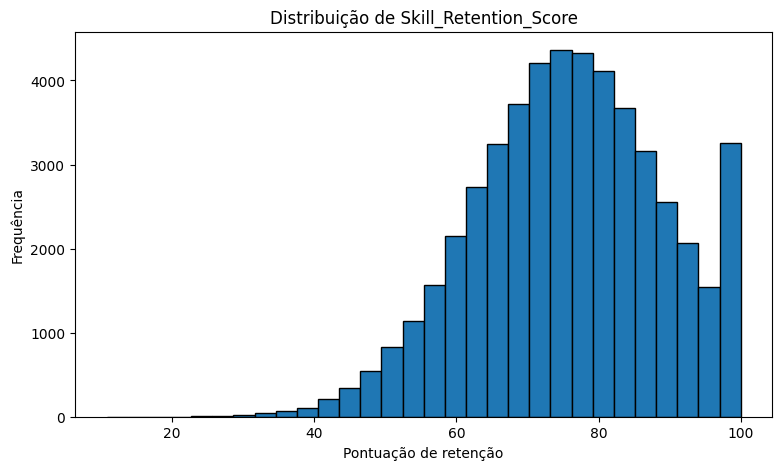

count    50000.000000
mean        75.798125
std         13.281626
min         10.780000
25%         66.820000
50%         76.000000
75%         85.190000
max        100.000000
Name: Skill_Retention_Score, dtype: float64
Assimetria: -0.215


In [11]:
alvo = "Skill_Retention_Score"

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df[alvo].dropna(), bins=30, edgecolor="black")
ax.set_title("Distribuição de Skill_Retention_Score")
ax.set_xlabel("Pontuação de retenção")
ax.set_ylabel("Frequência")
plt.show()

print(df[alvo].describe())
print("Assimetria:", round(df[alvo].skew(), 3))

**Interpretação:** o histograma mostra como os valores de retenção estão distribuídos. Em regressão não se analisa desbalanceamento de classes, mas é importante verificar concentração excessiva em uma faixa, assimetria, caudas longas e valores extremos.

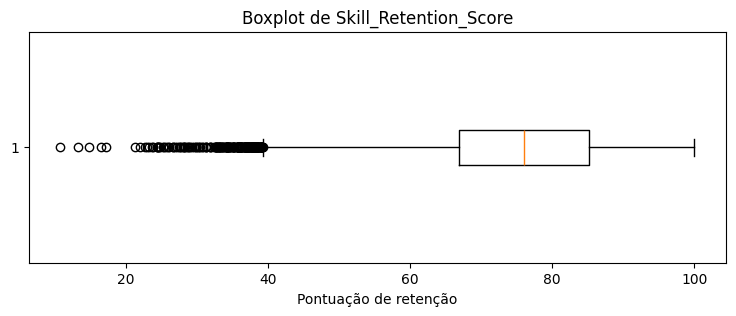

In [12]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.boxplot(df[alvo].dropna(), vert=False)
ax.set_title("Boxplot de Skill_Retention_Score")
ax.set_xlabel("Pontuação de retenção")
plt.show()

**Interpretação:** o boxplot ajuda a identificar observações distantes dos quartis. Esses pontos não serão removidos automaticamente, pois podem representar estudantes reais. A remoção só seria justificável caso fossem erros de registro.

# 5. Análise exploratória
A análise exploratória investiga relações entre os atributos e o alvo. Os gráficos não provam causalidade; eles apenas mostram padrões presentes no conjunto de dados.

# Correlação entre variáveis numéricas



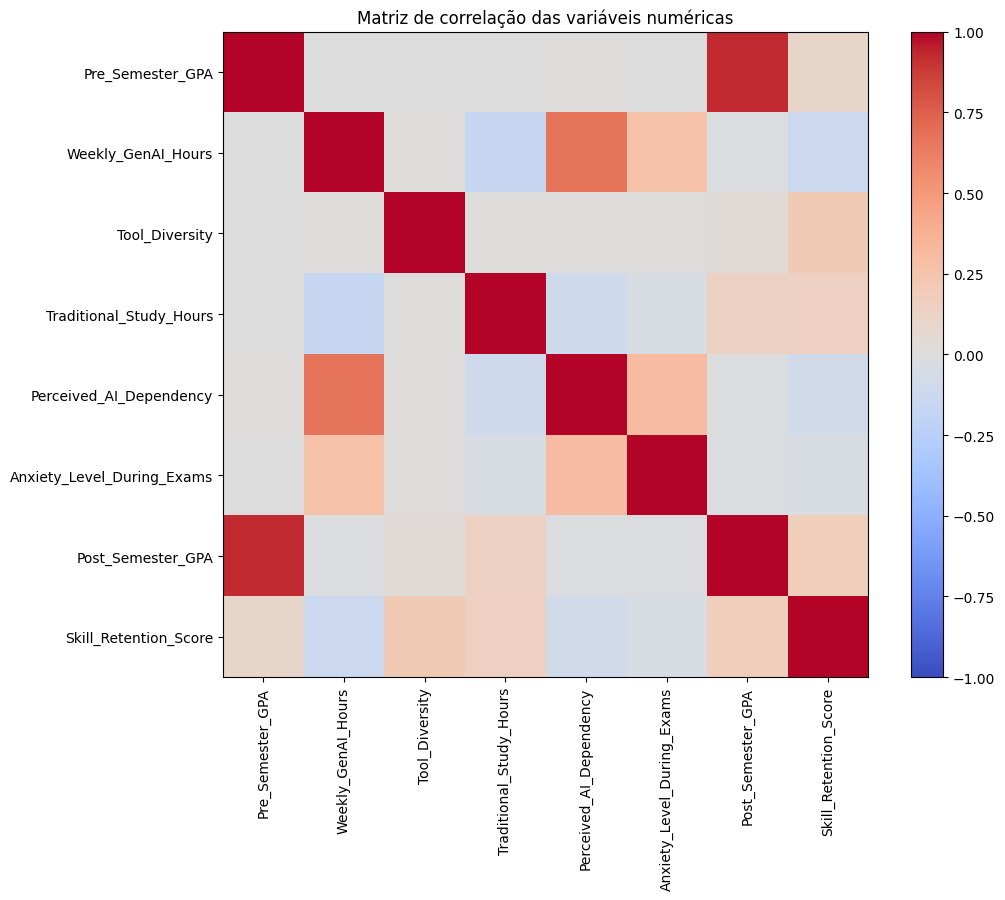

,correlação com o alvo
Tool_Diversity,0.196952
Post_Semester_GPA,0.169616
Traditional_Study_Hours,0.147565
Weekly_GenAI_Hours,-0.118099
Pre_Semester_GPA,0.099019
Perceived_AI_Dependency,-0.084324
Anxiety_Level_During_Exams,-0.041556


In [13]:
numericas = df.select_dtypes(include=np.number).drop(columns=["Student_ID"], errors="ignore")
correlacao = numericas.corr()

fig, ax = plt.subplots(figsize=(11, 9))
imagem = ax.imshow(correlacao, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlacao.columns)))
ax.set_yticks(range(len(correlacao.columns)))
ax.set_xticklabels(correlacao.columns, rotation=90)
ax.set_yticklabels(correlacao.columns)
ax.set_title("Matriz de correlação das variáveis numéricas")
fig.colorbar(imagem, ax=ax)
plt.tight_layout()
plt.show()

display(
    correlacao[alvo]
    .drop(alvo)
    .sort_values(key=abs, ascending=False)
    .to_frame("correlação com o alvo")
)

Interpretação: coeficientes próximos de 1 ou -1 indicam relações lineares fortes; valores próximos de zero indicam pouca relação linear. Uma correlação baixa não significa necessariamente que o atributo é inútil, pois árvores e florestas conseguem modelar relações não lineares.


# Relação entre horas de IA e retenção

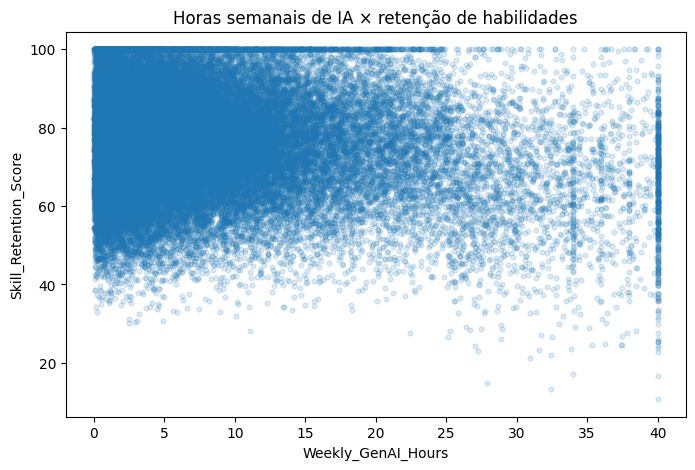

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df["Weekly_GenAI_Hours"],
    df[alvo],
    alpha=0.15,
    s=12
)
ax.set_title("Horas semanais de IA × retenção de habilidades")
ax.set_xlabel("Weekly_GenAI_Hours")
ax.set_ylabel(alvo)
plt.show()

Interpretação: o gráfico permite observar se o aumento do uso semanal de IA está associado a crescimento, redução ou ausência de mudança clara na retenção. A dispersão dos pontos também indica que uma única variável provavelmente não explica todo o resultado.

# Relação entre estudo tradicional e retenção

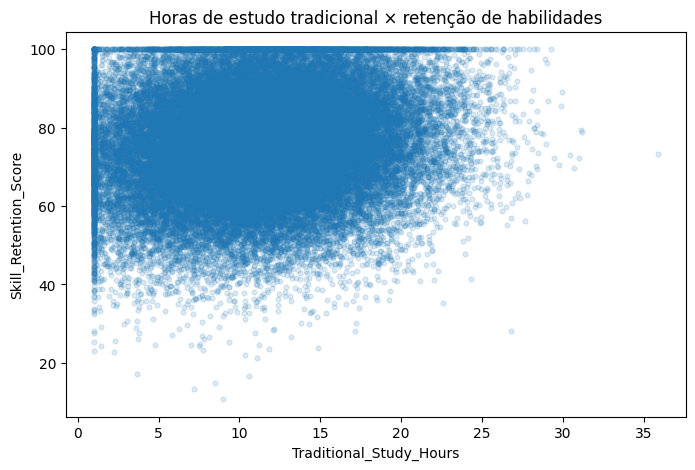

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df["Traditional_Study_Hours"],
    df[alvo],
    alpha=0.15,
    s=12
)
ax.set_title("Horas de estudo tradicional × retenção de habilidades")
ax.set_xlabel("Traditional_Study_Hours")
ax.set_ylabel(alvo)
plt.show()

Interpretação: este gráfico permite comparar o papel do estudo tradicional com o uso de IA. Uma tendência crescente sugeriria associação positiva, mas não seria suficiente para afirmar causalidade.

# Retenção por ano de estudo

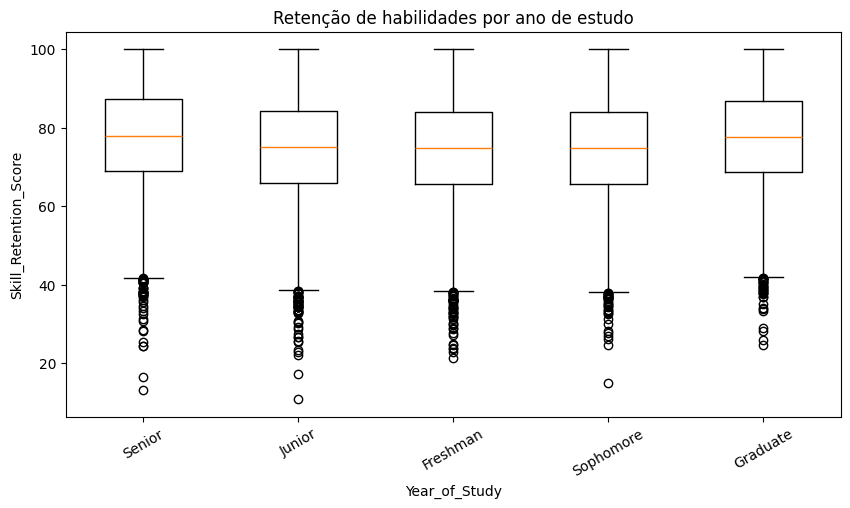

,count,mean,median,std
Year_of_Study,,,,
Senior,10634,77.767569,78.01,13.065275
Graduate,7430,77.508327,77.57,13.025990
Sophomore,9860,74.812019,74.91,13.215137
Junior,11045,74.770024,75.03,13.305287
Freshman,11031,74.658473,74.72,13.360344


In [16]:
ordem_anos = list(df["Year_of_Study"].dropna().unique())
dados_boxplot = [
    df.loc[df["Year_of_Study"] == categoria, alvo].dropna()
    for categoria in ordem_anos
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(dados_boxplot, labels=ordem_anos)
ax.set_title("Retenção de habilidades por ano de estudo")
ax.set_xlabel("Year_of_Study")
ax.set_ylabel(alvo)
plt.xticks(rotation=30)
plt.show()

display(
    df.groupby("Year_of_Study")[alvo]
      .agg(["count", "mean", "median", "std"])
      .sort_values("mean", ascending=False)
)

Interpretação: os boxplots e as medidas agrupadas permitem comparar a posição central e a dispersão da retenção entre os anos acadêmicos. Diferenças visuais devem ser tratadas como associações, não como prova de que o ano de estudo causa maior retenção.

# Retenção por habilidade de engenharia de prompts

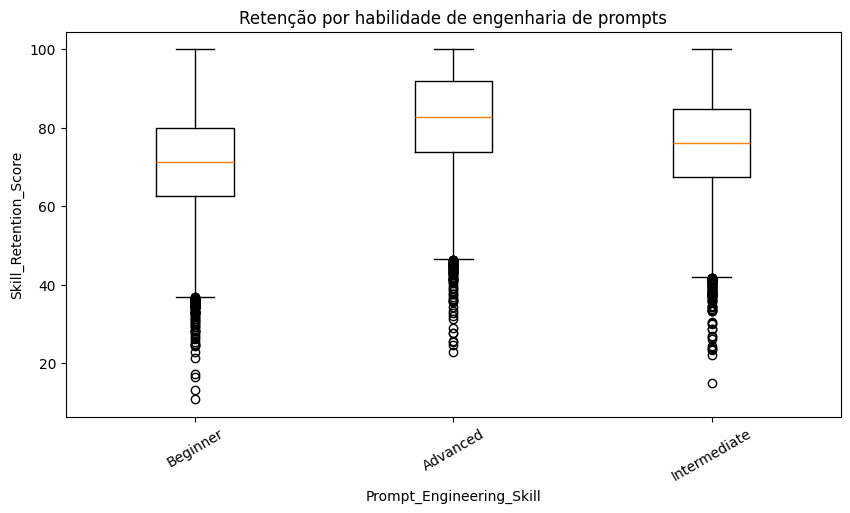

,count,mean,median,std
Prompt_Engineering_Skill,,,,
Advanced,13809,82.054186,82.730,12.533552
Intermediate,17696,75.824977,76.055,12.430620
Beginner,18495,71.101443,71.320,12.668497


In [17]:
ordem_prompt = list(df["Prompt_Engineering_Skill"].dropna().unique())
dados_boxplot = [
    df.loc[df["Prompt_Engineering_Skill"] == categoria, alvo].dropna()
    for categoria in ordem_prompt
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(dados_boxplot, labels=ordem_prompt)
ax.set_title("Retenção por habilidade de engenharia de prompts")
ax.set_xlabel("Prompt_Engineering_Skill")
ax.set_ylabel(alvo)
plt.xticks(rotation=30)
plt.show()

display(
    df.groupby("Prompt_Engineering_Skill")[alvo]
      .agg(["count", "mean", "median", "std"])
      .sort_values("mean", ascending=False)
)

Interpretação: esta análise verifica se estudantes com diferentes níveis de habilidade em formular prompts apresentam distribuições distintas de retenção.

# Retenção por principal caso de uso da IA

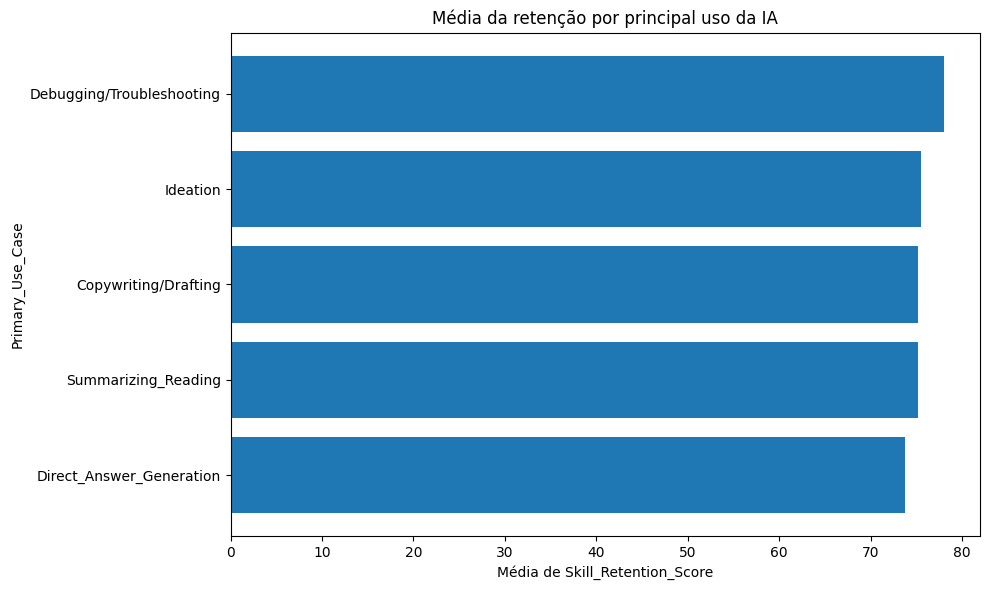

,count,mean,median,std
Primary_Use_Case,,,,
Direct_Answer_Generation,6340,73.718877,74.415,14.301480
Summarizing_Reading,8633,75.225024,75.540,12.699358
Copywriting/Drafting,12011,75.231097,75.410,12.722942
Ideation,10721,75.520224,75.740,12.641945
Debugging/Troubleshooting,12295,78.068964,78.200,13.900713


In [18]:
resumo_uso = (
    df.groupby("Primary_Use_Case")[alvo]
      .agg(["count", "mean", "median", "std"])
      .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(resumo_uso.index, resumo_uso["mean"])
ax.set_title("Média da retenção por principal uso da IA")
ax.set_xlabel("Média de Skill_Retention_Score")
ax.set_ylabel("Primary_Use_Case")
plt.tight_layout()
plt.show()

display(resumo_uso)

Interpretação: as médias permitem comparar os principais usos da IA. A quantidade de registros por categoria também deve ser observada, pois médias de grupos muito pequenos são menos estáveis.

# 6. Pré-processamento

# Problemas e tratamentos



1.   Identificador: Student_ID não representa uma característica útil do estudante e será removido.

1.  Possível vazamento temporal: Post_Semester_GPA e Burnout_Risk_Level serão removidos para simular uma previsão anterior à avaliação final.
2.   Valores ausentes: mediana para variáveis numéricas e moda para categóricas.


2.  Variáveis categóricas: codificação OneHotEncoder.

1.   Escalonamento: StandardScaler nas variáveis numéricas, importante para a regressão linear.

1.   Categorias desconhecidas: handle_unknown="ignore" evita falhas quando uma categoria aparece apenas no teste.
2.   Vazamento entre treino e teste: todas as transformações serão ajustadas somente nos dados de treinamento por meio de Pipeline e ColumnTransformer.



Os valores extremos não serão removidos automaticamente. A exclusão só seria feita caso fossem confirmados erros de registro.



In [19]:
COLUNAS_REMOVIDAS = [
    "Student_ID",
    "Post_Semester_GPA",
    "Burnout_Risk_Level"
]

X = df.drop(columns=[alvo] + COLUNAS_REMOVIDAS, errors="ignore")
y = df[alvo].copy()

colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Atributos numéricos:", colunas_numericas)
print("\nAtributos categóricos:", colunas_categoricas)
print("\nDimensão de X:", X.shape)

Atributos numéricos: ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']

Atributos categóricos: ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy']

Dimensão de X: (50000, 12)


In [20]:
pipeline_numerica = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("escalonamento", StandardScaler())
])

pipeline_categorica = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerica, colunas_numericas),
        ("categoricas", pipeline_categorica, colunas_categoricas)
    ],
    remainder="drop"
)

preprocessador

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputacao',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalonamento',
                                                  StandardScaler())]),
                                 ['Pre_Semester_GPA', 'Weekly_GenAI_Hours',
                                  'Tool_Diversity', 'Traditional_Study_Hours',
                                  'Perceived_AI_Dependency',
                                  'Anxiety_Level_During_Exams']),
                                ('categoricas',
                                 Pipeline(steps=[('imputacao',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Major_Category', 'Year_of_Study',
                                  'Primary_Use_Case',
                                  'Prompt_Engineering_Skill',
                                  'Paid_Subscription',
                                  'Institutional_Policy'])])

# 7. Separação dos dados
Será utilizada a proporção de 80% para treinamento e 20% para teste. O conjunto de teste permanecerá reservado até a avaliação final.

Como o alvo é contínuo, não há classes para estratificar. A comparação dos modelos será feita por validação cruzada com cinco divisões no conjunto de treinamento.

In [21]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Treino:", X_treino.shape, y_treino.shape)
print("Teste:", X_teste.shape, y_teste.shape)

Treino: (40000, 12) (40000,)
Teste: (10000, 12) (10000,)
